<a href="https://colab.research.google.com/github/darshanlahamage/Adaptive-Adversarial-Augmentation/blob/main/alsp_aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os, math, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF
from tqdm import tqdm

def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Initialized on Device: {device}")
    if torch.cuda.is_available():
        print(f"[*] CUDA Device Name: {torch.cuda.get_device_name(0)}")
    return device

device = get_device()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"[*] Random seed set to {seed} for reproducibility.")

set_seed(42)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

[*] Initialized on Device: cuda
[*] CUDA Device Name: Tesla T4
[*] Random seed set to 42 for reproducibility.


In [5]:
def compute_ece(probs, correct, n_bins=15):
    bin_edges = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    n = probs.shape[0]
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0: continue
        acc = correct[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)

def compute_failure_diversity(features, pred_labels, true_labels, n_clusters=10, pca_dim=64):
    """
    Computes Failure Diversity Score (FDS) using Normalized Entropy.
    Returns a score between 0.0 (all failures look the same) and 1.0 (highly diverse failures).
    """
    mask = pred_labels != true_labels
    if mask.sum() == 0: return 0.0, 0
    X = features[mask]
    n_samples = X.shape[0]
    pca_dim = min(pca_dim, X.shape[1])

    if n_samples <= 2: return 0.0, int(n_samples)

    pca = PCA(n_components=pca_dim, random_state=0)
    Xr = pca.fit_transform(X)

    k = min(n_clusters, max(2, n_samples // 10))
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(Xr)
    counts = np.bincount(kmeans.labels_, minlength=k)
    probs = counts / counts.sum()

    # Calculate Normalized Entropy
    ent = -np.sum([p * math.log(p + 1e-12) for p in probs if p > 0])
    max_ent = math.log(k)
    return float(ent / (max_ent + 1e-12)), int(n_samples)

In [6]:
class LatentStyleGenerator(nn.Module):
    def __init__(self, num_channels=128, bottleneck=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_channels * 2, bottleneck),
            nn.BatchNorm1d(bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, bottleneck),
            nn.BatchNorm1d(bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, num_channels * 2)
        )

    def forward(self, mu, std):
        B, C, _, _ = mu.shape
        x = torch.cat([mu.view(B, C), std.view(B, C)], dim=1)
        out = self.mlp(x)

        d_gamma = out[:, :C].view(B, C, 1, 1)
        d_beta = out[:, C:].view(B, C, 1, 1)

        # Bounded adversarial shifts
        d_gamma = torch.tanh(d_gamma) * 0.5
        d_beta = torch.tanh(d_beta) * 0.5
        return d_gamma, d_beta

class HookedResNetALSP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_feats = self.model.fc.in_features
        self.model.fc = nn.Linear(in_feats, num_classes)

        self.hook_channels = 128 # Channels at layer2
        self.generator = LatentStyleGenerator(num_channels=self.hook_channels)
        self.apply_adv_style = False
        self._register_hook()

    def _register_hook(self):
        def alsp_hook(module, input_tensor, output_tensor):
            if not self.apply_adv_style:
                return output_tensor

            z = output_tensor
            mu = torch.mean(z, dim=[2, 3], keepdim=True)
            std = torch.std(z, dim=[2, 3], keepdim=True) + 1e-6
            z_norm = (z - mu) / std

            d_gamma, d_beta = self.generator(mu, std)
            z_adv = z_norm * (std * (1.0 + d_gamma)) + (mu + d_beta)

            self.last_d_gamma = d_gamma
            self.last_d_beta = d_beta
            return z_adv

        self.hook_handle = self.model.layer2.register_forward_hook(alsp_hook)

    def forward(self, x):
        return self.model(x)

    def forward_with_features(self, x):
        """Safely extracts the penultimate 1D features for FDS scoring."""
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)
        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        x = self.model.layer4(x)
        x = self.model.avgpool(x)

        features = torch.flatten(x, 1)
        logits = self.model.fc(features)
        return logits, features

In [7]:
class HookedResNetALSP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_feats = self.model.fc.in_features
        self.model.fc = nn.Linear(in_feats, num_classes)

        self.hook_channels = 128
        self.generator = LatentStyleGenerator(num_channels=self.hook_channels)
        self.apply_adv_style = False
        self._register_hook()

    def _register_hook(self):
        def alsp_hook(module, input_tensor, output_tensor):
            if not self.apply_adv_style:
                return output_tensor

            z = output_tensor
            mu = torch.mean(z, dim=[2, 3], keepdim=True)
            std = torch.std(z, dim=[2, 3], keepdim=True) + 1e-6
            z_norm = (z - mu) / std

            d_gamma, d_beta = self.generator(mu, std)
            z_adv = z_norm * (std * (1.0 + d_gamma)) + (mu + d_beta)

            self.last_d_gamma = d_gamma
            self.last_d_beta = d_beta
            return z_adv

        self.hook_handle = self.model.layer2.register_forward_hook(alsp_hook)

    def forward(self, x):
        return self.model(x)

    def forward_with_features(self, x):
        """Safely extracts the penultimate 1D features for FDS scoring."""
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)
        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        x = self.model.layer4(x)
        x = self.model.avgpool(x)

        features = torch.flatten(x, 1)
        logits = self.model.fc(features)
        return logits, features

In [8]:
cifar_mean = np.array([0.4914, 0.4822, 0.4465])
cifar_std  = np.array([0.2470, 0.2435, 0.2616])

def get_cifar10_loaders(data_dir="./data", batch_size=128):
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std)
    ])
    train_ds = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=test_tf)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    return train_loader, test_loader

def evaluate_model(wrapper_model, loader, device):
    wrapper_model.eval()
    wrapper_model.apply_adv_style = False # CRITICAL: Turn off generator for testing!

    total, correct = 0, 0
    confs, correct_flags, all_feats, all_preds, all_trues = [], [], [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits, feats = wrapper_model.forward_with_features(images)
            probs = F.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

            correct_batch = pred.eq(labels)
            total += images.size(0)
            correct += correct_batch.sum().item()

            confs.append(conf.cpu().numpy())
            correct_flags.append(correct_batch.cpu().numpy())
            all_feats.append(feats.cpu().numpy())
            all_preds.append(pred.cpu().numpy())
            all_trues.append(labels.cpu().numpy())

    acc = correct / total
    confs, correct_flags = np.concatenate(confs), np.concatenate(correct_flags)
    ece = compute_ece(confs, correct_flags)
    return acc, ece, np.concatenate(all_feats, axis=0), np.concatenate(all_preds, axis=0), np.concatenate(all_trues, axis=0)

def train_alsp_epoch(train_loader, wrapper, opt_clf, opt_gen, criterion, epoch, device, lambda_reg=10.0):
    wrapper.train()
    stats = {"loss_clf_clean": [], "loss_clf_adv": [], "loss_gen": [], "reg_penalty": []}
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # PHASE 1: Clean Classifier Update
        wrapper.apply_adv_style = False
        opt_clf.zero_grad()
        loss_clean = criterion(wrapper(images), labels)
        loss_clean.backward()
        opt_clf.step()
        stats["loss_clf_clean"].append(loss_clean.item())

        # PHASE 2: Adversarial Classifier Update
        wrapper.apply_adv_style = True
        for p in wrapper.generator.parameters(): p.requires_grad = False
        opt_clf.zero_grad()
        loss_adv_clf = criterion(wrapper(images), labels)
        loss_adv_clf.backward()
        opt_clf.step()
        stats["loss_clf_adv"].append(loss_adv_clf.item())

        # PHASE 3: Generator Update
        for p in wrapper.generator.parameters(): p.requires_grad = True
        for p in wrapper.model.parameters(): p.requires_grad = False
        opt_gen.zero_grad()
        loss_adv_gen = criterion(wrapper(images), labels)

        reg_penalty = torch.mean(wrapper.last_d_gamma**2) + torch.mean(wrapper.last_d_beta**2)
        loss_gen = -loss_adv_gen + (lambda_reg * reg_penalty)
        loss_gen.backward()
        opt_gen.step()

        for p in wrapper.model.parameters(): p.requires_grad = True

        stats["loss_gen"].append(loss_adv_gen.item())
        stats["reg_penalty"].append(reg_penalty.item())
        pbar.set_postfix({"Clf(C)": f"{loss_clean.item():.3f}", "Clf(A)": f"{loss_adv_clf.item():.3f}"})

    return {k: float(np.mean(v)) for k, v in stats.items()}

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
def plot_and_save_history(history, save_dir):
    """Generates a professional plot of the loss curves to prove the Generator works."""
    epochs = range(1, len(history['test_acc']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Classifier Losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss_clf_clean'], label='Clean Loss', color='blue')
    plt.plot(epochs, history['loss_clf_adv'], label='Adversarial Loss', color='red')
    plt.title('Classifier Loss (Clean vs Adv)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Accuracy & FDS
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['test_acc'], label='Test Accuracy', color='green')
    plt.plot(epochs, history['fds'], label='Failure Diversity (FDS)', color='purple')
    plt.title('Performance Metrics')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=300)
    plt.close()

In [5]:
# def train_alsp_epoch(train_loader, wrapper, opt_clf, opt_gen, criterion, epoch, device, lambda_reg=10.0):
#     wrapper.train()
#     stats = {"loss_clf_clean": [], "loss_clf_adv": [], "loss_gen": [], "reg_penalty": []}

#     pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)

#     for images, labels in pbar:
#         images, labels = images.to(device), labels.to(device)

#         # -----------------------------------------------------------------
#         # PHASE 1: Train Classifier on CLEAN Data (Standard Learning)
#         # -----------------------------------------------------------------
#         wrapper.apply_adv_style = False
#         opt_clf.zero_grad()

#         logits_clean = wrapper(images)
#         loss_clean = criterion(logits_clean, labels)
#         loss_clean.backward()
#         opt_clf.step()

#         stats["loss_clf_clean"].append(loss_clean.item())

#         # -----------------------------------------------------------------
#         # PHASE 2: Train Classifier on ADVERSARIAL Data (Robustness Learning)
#         # -----------------------------------------------------------------
#         wrapper.apply_adv_style = True

#         # Freeze Generator so it doesn't learn during the classifier's turn
#         for p in wrapper.generator.parameters(): p.requires_grad = False

#         opt_clf.zero_grad()
#         logits_adv = wrapper(images)
#         loss_adv_clf = criterion(logits_adv, labels)
#         loss_adv_clf.backward()
#         opt_clf.step()

#         stats["loss_clf_adv"].append(loss_adv_clf.item())

#         # -----------------------------------------------------------------
#         # PHASE 3: Train Generator (The Attacker)
#         # -----------------------------------------------------------------
#         # Unfreeze Generator, Freeze Classifier
#         for p in wrapper.generator.parameters(): p.requires_grad = True
#         for p in wrapper.model.parameters(): p.requires_grad = False

#         opt_gen.zero_grad()
#         logits_gen_adv = wrapper(images)
#         loss_adv_gen = criterion(logits_gen_adv, labels)

#         # Penalty: Keep the adversarial shifts small so we don't destroy the latent space
#         reg_penalty = torch.mean(wrapper.last_d_gamma**2) + torch.mean(wrapper.last_d_beta**2)

#         # Objective: Maximize Classifier Loss (so we negate it) + minimize penalty
#         loss_gen = -loss_adv_gen + (lambda_reg * reg_penalty)
#         loss_gen.backward()
#         opt_gen.step()

#         # Unfreeze Classifier for the next batch
#         for p in wrapper.model.parameters(): p.requires_grad = True

#         stats["loss_gen"].append(loss_adv_gen.item())
#         stats["reg_penalty"].append(reg_penalty.item())

#         pbar.set_postfix({
#             "Clf(Cln)": f"{loss_clean.item():.3f}",
#             "Clf(Adv)": f"{loss_adv_clf.item():.3f}",
#             "Gen": f"{loss_adv_gen.item():.3f}",
#             "Reg": f"{reg_penalty.item():.4f}"
#         })

#     return {k: float(np.mean(v)) for k, v in stats.items()}

In [10]:
import json

def run_final_alsp_experiment(epochs=50, save_dir="./runs-alsp-aug/alsp_final"):
    ensure_dir(save_dir)
    train_loader, test_loader = get_cifar10_loaders(batch_size=128)

    wrapper = HookedResNetALSP(num_classes=10).to(device)
    opt_clf = optim.SGD(wrapper.model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
    opt_gen = optim.Adam(wrapper.generator.parameters(), lr=1e-3)
    scheduler_clf = optim.lr_scheduler.CosineAnnealingLR(opt_clf, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'loss_clf_clean': [], 'loss_clf_adv': [], 'test_acc': [], 'fds': [], 'ece': []}
    best_acc = 0.0

    print(f"[*] Starting ALSP Training. Artifacts will be saved to: {save_dir}")
    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Train
        agg = train_alsp_epoch(train_loader, wrapper, opt_clf, opt_gen, criterion, epoch, device, lambda_reg=10.0)
        scheduler_clf.step()

        # Evaluate
        acc, ece, feats, pred_arr, true_arr = evaluate_model(wrapper, test_loader, device)
        fds, n_fail = compute_failure_diversity(feats, pred_arr, true_arr, n_clusters=10)

        # Log History
        history['loss_clf_clean'].append(agg['loss_clf_clean'])
        history['loss_clf_adv'].append(agg['loss_clf_adv'])
        history['test_acc'].append(acc)
        history['fds'].append(fds)
        history['ece'].append(ece)

        print(f"Epoch {epoch:02d} | Time: {time.time()-t0:.1f}s | "
              f"Clf(C): {agg['loss_clf_clean']:.4f} | Clf(A): {agg['loss_clf_adv']:.4f} | "
              f"Acc: {acc:.4f} | ECE: {ece:.4f} | FDS: {fds:.4f}")

        # Save Best Checkpoint
        if acc > best_acc:
            best_acc = acc
            torch.save({
                'epoch': epoch,
                'model_state': wrapper.model.state_dict(),
                'gen_state': wrapper.generator.state_dict(),
                'best_acc': best_acc
            }, os.path.join(save_dir, 'best_alsp_ckpt.pth'))

    # Save final artifacts at the end of training
    with open(os.path.join(save_dir, 'history.json'), 'w') as f:
        json.dump(history, f)
    plot_and_save_history(history, save_dir)
    print(f"[*] Training Complete. Best Accuracy: {best_acc:.4f}. Artifacts saved.")

# Execute!
run_final_alsp_experiment(epochs=30, save_dir="/content/drive/My Drive/alsp_training_runs")

100%|██████████| 170M/170M [00:05<00:00, 28.9MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


[*] Starting ALSP Training. Artifacts will be saved to: /content/drive/My Drive/alsp_training_runs


Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

Epoch 28 | Time: 64.4s | Clf(C): 0.3187 | Clf(A): 0.3205 | Acc: 0.8464 | ECE: 0.0392 | FDS: 0.9758


Epoch 29:   0%|          | 0/391 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 29 | Time: 63.9s | Clf(C): 0.3038 | Clf(A): 0.3151 | Acc: 0.8489 | ECE: 0.0388 | FDS: 0.9791


Epoch 30:   0%|          | 0/391 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 30 | Time: 63.9s | Clf(C): 0.2988 | Clf(A): 0.5747 | Acc: 0.8482 | ECE: 0.0412 | FDS: 0.9654
[*] Training Complete. Best Accuracy: 0.8489. Artifacts saved.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import urllib.request
import tarfile

def download_and_extract_cifar10c(data_dir='./data/cifar10-c'):
    ensure_dir(data_dir)
    url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar?download=1"
    tar_path = os.path.join(data_dir, "CIFAR-10-C.tar")

    if not os.path.exists(os.path.join(data_dir, 'CIFAR-10-C', 'labels.npy')):
        print("[*] Downloading CIFAR-10-C... This may take a few minutes (approx 2.7GB).")
        urllib.request.urlretrieve(url, tar_path)
        print("[*] Download complete. Extracting...")
        with tarfile.open(tar_path) as tar:
            tar.extractall(path=data_dir)
        print("[*] Extraction complete.")
    else:
        print("[*] CIFAR-10-C already exists locally.")

    return os.path.join(data_dir, 'CIFAR-10-C')


def evaluate_robustness_official(wrapper_model, device, severity=5):
    print(f"\n{'='*50}")
    print(f" OFFICIAL CIFAR-10-C ROBUSTNESS TEST (Severity {severity})")
    print(f"{'='*50}")

    wrapper_model.eval()
    wrapper_model.apply_adv_style = False # Turn off the hook!

    cifar10_c_dir = download_and_extract_cifar10c()

    corruptions = [
        'gaussian_noise', 'shot_noise', 'impulse_noise', 'defocus_blur', 'glass_blur',
        'motion_blur', 'zoom_blur', 'snow', 'frost', 'fog', 'brightness', 'contrast',
        'elastic_transform', 'pixelate', 'jpeg_compression', 'speckle_noise',
        'gaussian_blur', 'spatter', 'saturate'
    ]

    # CIFAR-10-C data is arranged in blocks of 10,000 images per severity level (1-5)
    start_idx = (severity - 1) * 10000
    end_idx = severity * 10000

    labels_path = os.path.join(cifar10_c_dir, 'labels.npy')
    all_labels = np.load(labels_path)[start_idx:end_idx]

    # THE FIX: Explicitly cast the mean and std to 32-bit floats
    mean = torch.tensor(cifar_mean, dtype=torch.float32).view(1,3,1,1).to(device)
    std  = torch.tensor(cifar_std, dtype=torch.float32).view(1,3,1,1).to(device)

    results = {}

    with torch.no_grad():
        for corruption in corruptions:
            data_path = os.path.join(cifar10_c_dir, f'{corruption}.npy')
            if not os.path.exists(data_path):
                print(f"Warning: {corruption}.npy not found. Skipping.")
                continue

            # Load the specific severity block
            data = np.load(data_path)[start_idx:end_idx] # Shape: (10000, 32, 32, 3) in uint8

            # Convert to PyTorch format [B, C, H, W], normalize to [0,1]
            data_tensor = torch.from_numpy(data).permute(0, 3, 1, 2).float() / 255.0
            data_tensor = data_tensor.to(device)

            # Apply CIFAR standardization (now mathematically safe with 32-bit floats)
            data_tensor = (data_tensor - mean) / std

            labels_tensor = torch.from_numpy(all_labels).long().to(device)

            # Evaluate in chunks to avoid OOM errors
            chunk_size = 500
            correct = 0
            for i in range(0, 10000, chunk_size):
                chunk_data = data_tensor[i:i+chunk_size]
                chunk_labels = labels_tensor[i:i+chunk_size]

                preds = wrapper_model(chunk_data).argmax(dim=1)
                correct += preds.eq(chunk_labels).sum().item()

            acc = correct / 10000.0
            results[corruption] = acc
            print(f"[*] {corruption:<20}: {acc*100:.2f}%")

    mean_corruption_acc = np.mean(list(results.values()))
    print(f"{'-'*50}")
    print(f"[*] Mean Corruption Accuracy (MCA): {mean_corruption_acc*100:.2f}%")
    print(f"{'='*50}\n")
    return results

# Load the best checkpoint from our run
wrapper = HookedResNetALSP(num_classes=10).to(device)
ckpt = torch.load("/content/drive/MyDrive/alsp_training_runs/best_alsp_ckpt.pth", map_location=device)
wrapper.model.load_state_dict(ckpt['model_state'])

# Run the official test!
evaluate_robustness_official(wrapper, device, severity=5)


 OFFICIAL CIFAR-10-C ROBUSTNESS TEST (Severity 5)
[*] CIFAR-10-C already exists locally.
[*] gaussian_noise      : 61.13%
[*] shot_noise          : 63.75%
[*] impulse_noise       : 38.50%
[*] defocus_blur        : 53.00%
[*] glass_blur          : 61.23%
[*] motion_blur         : 58.76%
[*] zoom_blur           : 61.17%
[*] snow                : 73.01%
[*] frost               : 68.44%
[*] fog                 : 49.00%
[*] brightness          : 78.40%
[*] contrast            : 22.83%
[*] elastic_transform   : 72.58%
[*] pixelate            : 74.98%
[*] jpeg_compression    : 78.88%
[*] speckle_noise       : 62.67%
[*] gaussian_blur       : 48.84%
[*] spatter             : 65.08%
[*] saturate            : 73.48%
--------------------------------------------------
[*] Mean Corruption Accuracy (MCA): 61.35%



{'gaussian_noise': 0.6113,
 'shot_noise': 0.6375,
 'impulse_noise': 0.385,
 'defocus_blur': 0.53,
 'glass_blur': 0.6123,
 'motion_blur': 0.5876,
 'zoom_blur': 0.6117,
 'snow': 0.7301,
 'frost': 0.6844,
 'fog': 0.49,
 'brightness': 0.784,
 'contrast': 0.2283,
 'elastic_transform': 0.7258,
 'pixelate': 0.7498,
 'jpeg_compression': 0.7888,
 'speckle_noise': 0.6267,
 'gaussian_blur': 0.4884,
 'spatter': 0.6508,
 'saturate': 0.7348}

[*] Dashboard successfully saved in high resolution to: /content/drive/MyDrive/alsp_training_runs/advanced_dashboard.png


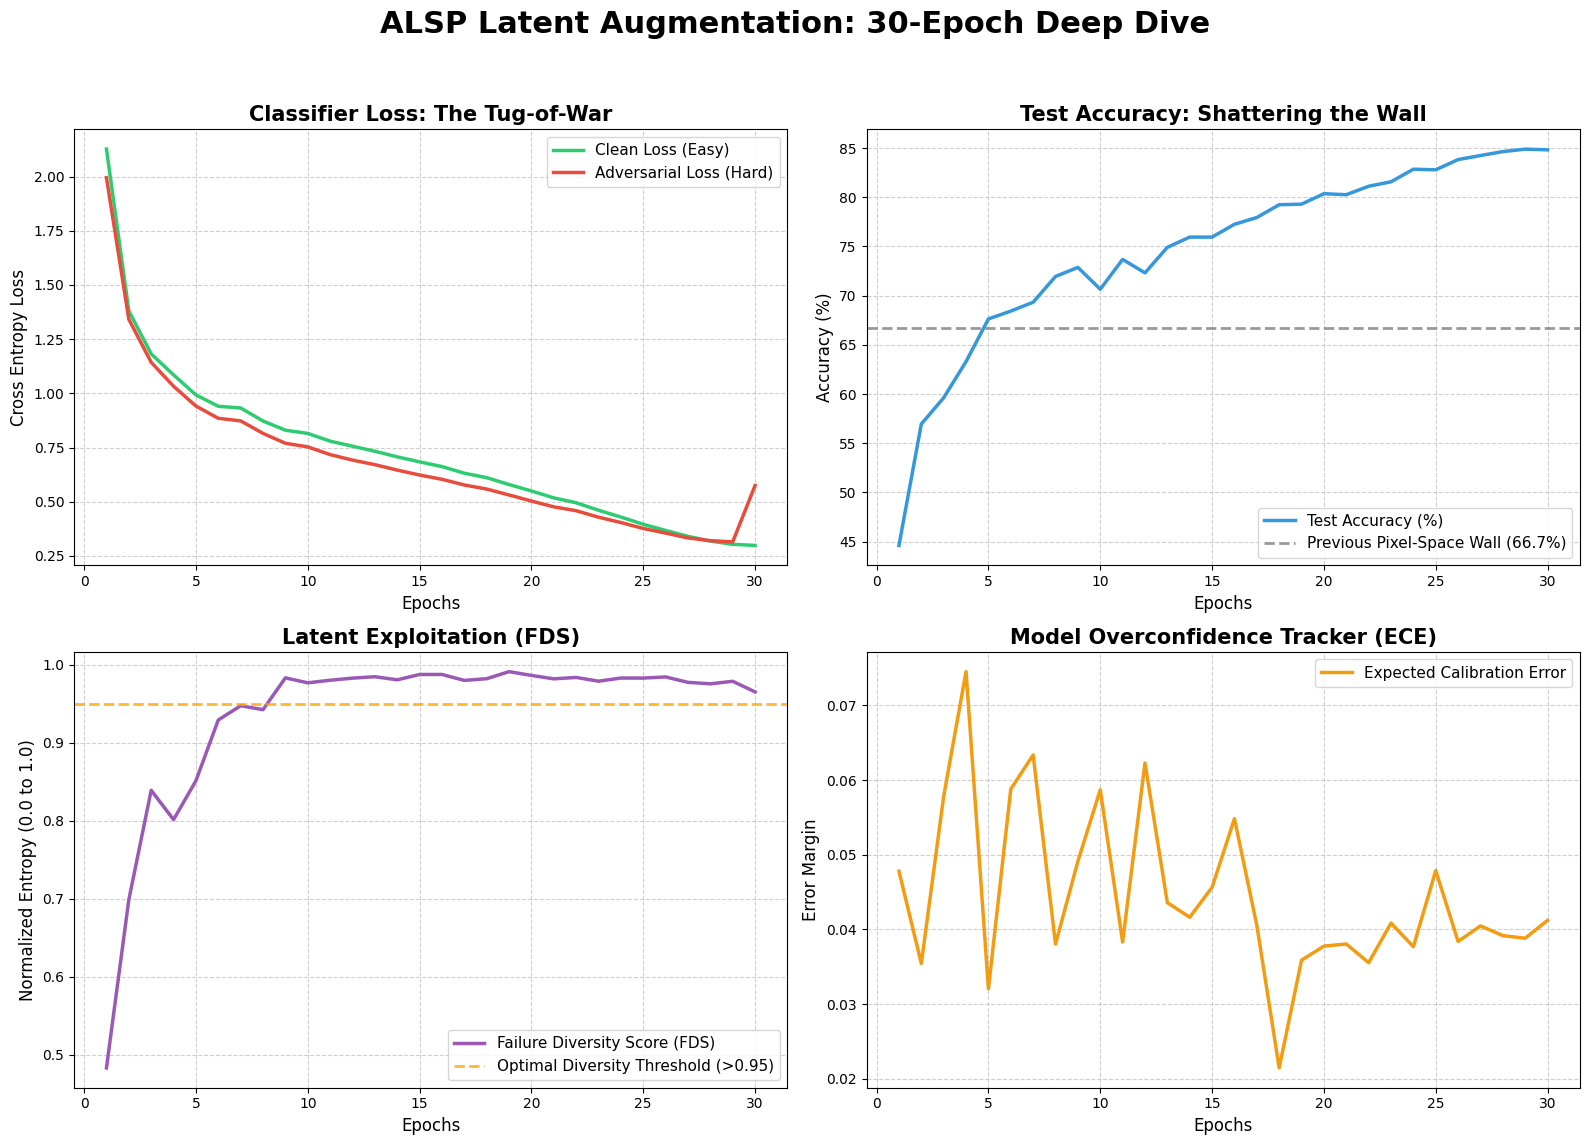

In [16]:
import json
import os
import matplotlib.pyplot as plt

def plot_advanced_dashboard(save_dir="./runs/alsp_final"):
    history_path = os.path.join(save_dir, 'history.json')
    if not os.path.exists(history_path):
        print(f"[*] Error: Could not find {history_path}. Please check your save_dir.")
        return

    # Load the metrics we saved during training
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['test_acc']) + 1)

    # Set up a professional 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ALSP Latent Augmentation: 30-Epoch Deep Dive', fontsize=22, fontweight='bold', y=0.98)

    # Plot 1: The Tug-of-War (Loss Dynamics)
    axs[0, 0].plot(epochs, history['loss_clf_clean'], label='Clean Loss (Easy)', color='#2ecc71', linewidth=2.5)
    axs[0, 0].plot(epochs, history['loss_clf_adv'], label='Adversarial Loss (Hard)', color='#e74c3c', linewidth=2.5)
    axs[0, 0].set_title('Classifier Loss: The Tug-of-War', fontsize=15, fontweight='bold')
    axs[0, 0].set_xlabel('Epochs', fontsize=12)
    axs[0, 0].set_ylabel('Cross Entropy Loss', fontsize=12)
    axs[0, 0].legend(loc='upper right', fontsize=11)
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2: The Learning Curve
    axs[0, 1].plot(epochs, [acc * 100 for acc in history['test_acc']], label='Test Accuracy (%)', color='#3498db', linewidth=2.5)
    axs[0, 1].axhline(y=66.7, color='gray', linestyle='--', alpha=0.8, linewidth=2, label='Previous Pixel-Space Wall (66.7%)')
    axs[0, 1].set_title('Test Accuracy: Shattering the Wall', fontsize=15, fontweight='bold')
    axs[0, 1].set_xlabel('Epochs', fontsize=12)
    axs[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axs[0, 1].legend(loc='lower right', fontsize=11)
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    # Plot 3: The Diversity Engine (FDS)
    axs[1, 0].plot(epochs, history['fds'], label='Failure Diversity Score (FDS)', color='#9b59b6', linewidth=2.5)
    axs[1, 0].axhline(y=0.95, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='Optimal Diversity Threshold (>0.95)')
    axs[1, 0].set_title('Latent Exploitation (FDS)', fontsize=15, fontweight='bold')
    axs[1, 0].set_xlabel('Epochs', fontsize=12)
    axs[1, 0].set_ylabel('Normalized Entropy (0.0 to 1.0)', fontsize=12)
    axs[1, 0].legend(loc='lower right', fontsize=11)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    # Plot 4: Model Calibration (ECE)
    axs[1, 1].plot(epochs, history['ece'], label='Expected Calibration Error', color='#f39c12', linewidth=2.5)
    axs[1, 1].set_title('Model Overconfidence Tracker (ECE)', fontsize=15, fontweight='bold')
    axs[1, 1].set_xlabel('Epochs', fontsize=12)
    axs[1, 1].set_ylabel('Error Margin', fontsize=12)
    axs[1, 1].legend(loc='upper right', fontsize=11)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    # Save and show
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    save_path = os.path.join(save_dir, 'advanced_dashboard.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[*] Dashboard successfully saved in high resolution to: {save_path}")
    plt.show()

plot_advanced_dashboard(save_dir="/content/drive/MyDrive/alsp_training_runs")